# Case Study 3: Random Walk

**Scenario:** A 500-point sequence where each value equals the previous plus a random step: Xₜ = Xₜ₋₁ + εₜ. This is non-stationary — the mean and variance grow without bound. It appears everywhere in finance (stock prices), physics (Brownian motion), and quality control (drift detection).

This case study demonstrates how the 4-plot reveals non-stationarity, and why applying standard tests to a random walk gives misleading results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

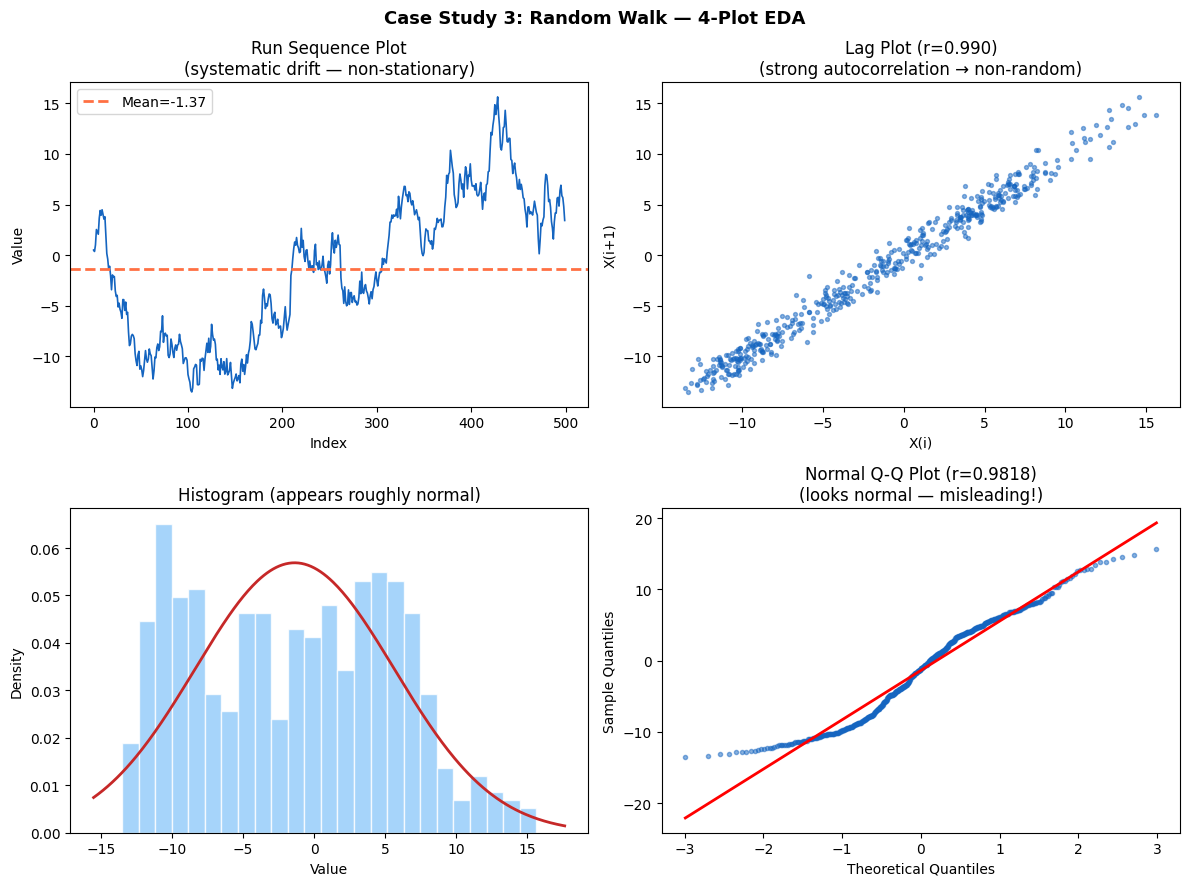

Random walk itself vs its steps:
  RW:    AD A²=5.9375  crit=0.7810  lag1_r=0.9902 → FAIL independence
  Steps: AD A²=0.2978 crit=0.7810  lag1_r=-0.0040 → PASS (white noise)

Spurious regression danger: regressing two independent random walks
  r²=0.471, p=0.0000 — spuriously significant despite independence!


In [2]:
np.random.seed(42)
n = 500
steps = np.random.normal(0, 1, n)
rw = np.cumsum(steps)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Case Study 3: Random Walk — 4-Plot EDA', fontsize=13, fontweight='bold')

axes[0,0].plot(rw, color='#1565C0', lw=1.2)
axes[0,0].axhline(rw.mean(), color='#FF7043', lw=2, ls='--', label=f'Mean={rw.mean():.2f}')
axes[0,0].set_title('Run Sequence Plot\n(systematic drift — non-stationary)')
axes[0,0].set_xlabel('Index'); axes[0,0].set_ylabel('Value')
axes[0,0].legend()

axes[0,1].scatter(rw[:-1], rw[1:], color='#1565C0', s=8, alpha=0.5)
r_lag = np.corrcoef(rw[:-1], rw[1:])[0, 1]
axes[0,1].set_title(f'Lag Plot (r={r_lag:.3f})\n(strong autocorrelation → non-random)')
axes[0,1].set_xlabel('X(i)'); axes[0,1].set_ylabel('X(i+1)')

axes[1,0].hist(rw, bins=25, density=True, color='#90CAF9', edgecolor='white', alpha=0.8)
x = np.linspace(rw.min()-2, rw.max()+2, 300)
axes[1,0].plot(x, stats.norm(rw.mean(), rw.std()).pdf(x), color='#C62828', lw=2)
axes[1,0].set_title('Histogram (appears roughly normal)')
axes[1,0].set_xlabel('Value'); axes[1,0].set_ylabel('Density')

(osm, osr), (slope, intercept, r) = stats.probplot(rw, dist='norm')
axes[1,1].plot(osm, osr, 'o', color='#1565C0', ms=3, alpha=0.5)
axes[1,1].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2)
axes[1,1].set_title(f'Normal Q-Q Plot (r={r:.4f})\n(looks normal — misleading!)')
axes[1,1].set_xlabel('Theoretical Quantiles'); axes[1,1].set_ylabel('Sample Quantiles')

plt.tight_layout(); plt.show()

# Show steps are white noise
print('Random walk itself vs its steps:')
ad_rw,   ad_crit_rw, _ = stats.anderson(rw, dist='norm')
ad_step, ad_crit_step, _ = stats.anderson(steps, dist='norm')
r_rw   = np.corrcoef(rw[:-1], rw[1:])[0, 1]
r_step = np.corrcoef(steps[:-1], steps[1:])[0, 1]
print(f'  RW:    AD A²={ad_rw:.4f}  crit={ad_crit_rw[2]:.4f}  lag1_r={r_rw:.4f} → FAIL independence')
print(f'  Steps: AD A²={ad_step:.4f} crit={ad_crit_step[2]:.4f}  lag1_r={r_step:.4f} → PASS (white noise)')
print()
print('Spurious regression danger: regressing two independent random walks')
rw2 = np.cumsum(np.random.normal(0, 1, n))
slope, intercept, r_xy, p_xy, _ = stats.linregress(rw, rw2)
print(f'  r²={r_xy**2:.3f}, p={p_xy:.4f} — spuriously significant despite independence!')

## Conclusions

| Check | Result | Notes |
|---|---|---|
| **Fixed location** | ❌ Fail | Run sequence shows clear drift |
| **Fixed variation** | ❌ Fail | Variance grows over time (non-stationary) |
| **Independence** | ❌ Fail | Lag-1 r ≈ 1; lag plot is diagonal line |
| **Normality** | ✅ Misleading pass | Q-Q looks fine — but that's a coincidence |

**Key lessons:** (1) The lag plot is the critical diagnostic for a random walk. (2) Difference the data (Xₜ − Xₜ₋₁) to recover white noise. (3) Never regress two random walks — spurious correlations are guaranteed.